# Бенчмарк Cross-Encoder для задачи семантического матчинга
## Оценка качества реранжирования: описание товара ↔ пост Telegram

**Цель работы:** систематическая оценка качества Cross-Encoder модели до и после дообучения (fine-tuning) на задаче семантического сопоставления описаний товаров/услуг с публикациями в Telegram-каналах.

В данном ноутбуке представлены:
1. Теоретические основы архитектуры Cross-Encoder и её отличия от Bi-Encoder
2. Обзор ключевых метрик оценки качества для задач STS, ранжирования и классификации
3. Практическая реализация бенчмарков с визуализацией результатов
4. Сравнительный анализ базовой и дообученной моделей

---
## 1. Архитектура Cross-Encoder

### 1.1. Общее описание

**Cross-Encoder** — это архитектура на базе трансформера, которая принимает на вход *пару текстов одновременно* и возвращает единственное скалярное значение — оценку релевантности (score). В отличие от **Bi-Encoder**, который кодирует каждый текст независимо в векторное представление (эмбеддинг), Cross-Encoder обрабатывает оба текста совместно через механизм полного внимания (full attention), что позволяет модели учитывать тонкие взаимосвязи между токенами обоих текстов.

Формально, для пары текстов $(A, B)$ Cross-Encoder вычисляет:

$$\text{score}(A, B) = \sigma\big(W \cdot \text{pool}(\text{Transformer}([\text{CLS}] \oplus A \oplus [\text{SEP}] \oplus B \oplus [\text{SEP}]))\big)$$

где $\sigma$ — функция активации (Sigmoid для регрессии, Softmax для классификации), $W$ — весовая матрица классификационной головы, $\text{pool}$ — пулинг по токену `[CLS]`.

### 1.2. Сравнение Cross-Encoder и Bi-Encoder

| Характеристика | Bi-Encoder | Cross-Encoder |
|---|---|---|
| **Входные данные** | Каждый текст кодируется отдельно | Оба текста подаются вместе |
| **Механизм внимания** | Self-attention внутри каждого текста | Cross-attention между обоими текстами |
| **Скорость** | Высокая (эмбеддинги предвычислены) | Низкая (требуется инференс для каждой пары) |
| **Качество** | Хорошее | Превосходное |
| **Применение** | Первичный поиск (retrieval) | Реранжирование (reranking) |
| **Масштабируемость** | $O(n)$ — линейная | $O(n \cdot m)$ — квадратичная |

### 1.3. Роль Cross-Encoder в рекомендательной системе

В пайплайне **Retrieve & Rerank** Cross-Encoder выступает в роли второго этапа:

1. **Retrieve (Bi-Encoder):** быстрый поиск Top-K кандидатов из корпуса постов по семантической близости эмбеддингов
2. **Rerank (Cross-Encoder):** точное ранжирование отобранных кандидатов с учётом глубокого взаимного внимания между описанием товара и текстом поста

Именно Cross-Encoder определяет финальное качество рекомендаций, поэтому его оценка через объективные метрики является критически важной задачей.

---
## 2. Метрики оценки качества Cross-Encoder

Оценка качества Cross-Encoder модели зависит от типа решаемой задачи. Ниже представлены основные группы метрик, применяемых в литературе и на практике.

### 2.1. Метрики семантической текстовой схожести (STS)

Задача **Semantic Textual Similarity (STS)** — оценка степени семантической близости двух текстов по непрерывной шкале $[0, 1]$. Эталонная задача — [STS Benchmark](https://ixa2.si.ehu.eus/stswiki/index.php/STSbenchmark) (Cer et al., 2017).

#### 2.1.1. Коэффициент корреляции Пирсона (Pearson $r$)

Измеряет **линейную** зависимость между предсказанными и истинными скорами:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

где $x_i$ — предсказанный скор, $y_i$ — эталонный скор.

- Диапазон: $[-1, 1]$; значение $+1$ означает идеальную положительную корреляцию
- **Чувствителен** к линейности зависимости и выбросам
- Показывает, насколько предсказания модели **пропорциональны** эталонным оценкам

#### 2.1.2. Коэффициент ранговой корреляции Спирмена (Spearman $\rho$)

Измеряет **монотонную** зависимость между ранжированиями, вычисляется как коэффициент Пирсона для рангов:

$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

где $d_i = \text{rank}(x_i) - \text{rank}(y_i)$ — разность рангов $i$-го наблюдения.

- Диапазон: $[-1, 1]$; значение $+1$ означает идеальное сохранение порядка
- **Устойчив** к нелинейным монотонным преобразованиям и выбросам
- **Основная метрика** для STS задач, так как важен именно **порядок**, а не абсолютные значения скоров

#### 2.1.3. Тау Кендалла (Kendall $\tau$)

Альтернативная ранговая корреляция, основанная на подсчёте конкордантных и дискордантных пар:

$$\tau = \frac{C - D}{\binom{n}{2}}$$

где $C$ — число конкордантных пар (пар с согласованным порядком), $D$ — число дискордантных пар.

- Более консервативная оценка, чем Spearman
- Значения обычно ниже, чем у Spearman для тех же данных
- Хорошо интерпретируется: $\tau = 0.7$ означает, что 85% пар упорядочены правильно

> **Обоснование для нашей задачи.** Наш датасет имеет структуру изолированных пар *(описание товара, пост, score)* с непрерывной оценкой релевантности $[0, 1]$. Корреляционные метрики — **единственная группа**, которая корректно работает с такой структурой напрямую, без реструктуризации данных. Spearman $\rho$ является приоритетной, поскольку для задачи реранжирования критично именно **сохранение порядка** — модель должна давать более высокий скор релевантным парам, а не предсказывать абсолютные значения. Это стандартная основная метрика на STS Benchmark (Cer et al., 2017) и в библиотеке sentence-transformers, где `CrossEncoderCorrelationEvaluator` использует Spearman $\rho$ как primary metric.

### 2.2. Метрики информационного поиска и ранжирования

Эти метрики оценивают качество *упорядочивания* документов (постов) по запросу (описанию товара) и широко применяются в задачах реранжирования.

#### 2.2.1. DCG и NDCG (Normalized Discounted Cumulative Gain)

**DCG** оценивает качество ранжирования с учётом позиции релевантного документа — чем выше он расположен, тем больше его вклад:

$$DCG@k = \sum_{i=1}^{k} \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$

**NDCG** нормализует DCG относительно идеального ранжирования (IDCG):

$$NDCG@k = \frac{DCG@k}{IDCG@k}$$

- Диапазон: $[0, 1]$; значение $1$ означает идеальное ранжирование
- Учитывает **позиционное затухание** — релевантный документ на 1-й позиции ценнее, чем на 10-й
- Работает с **градуированной** релевантностью (не только бинарной)
- Стандартная метрика на бенчмарках MS MARCO и TREC

#### 2.2.2. MRR (Mean Reciprocal Rank)

**MRR** оценивает, на какой позиции модель расположила *первый* релевантный документ:

$$MRR = \frac{1}{|Q|} \sum_{i=1}^{|Q|} \frac{1}{\text{rank}_i}$$

где $\text{rank}_i$ — позиция первого релевантного документа для $i$-го запроса.

- Диапазон: $(0, 1]$; значение $1$ — первый результат всегда релевантен
- Фокусируется на **верхней части** списка
- Не учитывает позиции остальных релевантных документов

#### 2.2.3. MAP (Mean Average Precision)

**MAP** — среднее значение Average Precision по всем запросам:

$$AP(q) = \frac{1}{|R_q|} \sum_{k=1}^{n} P@k \cdot \text{rel}(k)$$

$$MAP = \frac{1}{|Q|} \sum_{q=1}^{|Q|} AP(q)$$

- Учитывает **все** позиции релевантных документов, а не только первый
- Чувствителен к порядку релевантных документов на всех позициях

#### 2.2.4. Precision@k

Доля релевантных документов среди первых $k$ результатов:

$$P@k = \frac{|\{\text{relevant docs in top-}k\}|}{k}$$

- Простая и интуитивная метрика
- Не учитывает порядок внутри Top-$k$

#### 2.2.5. Применение метрик ранжирования к парным данным

> **Важный нюанс.** Метрики NDCG, MRR, MAP, P@k предполагают структуру «**один запрос → список кандидатов с оценками релевантности**». Если датасет состоит из изолированных пар $(q_i, d_i, s_i)$ без группировки по запросам, эти метрики **нельзя** применять напрямую.
>
> **Корректный подход — симуляция ранжирования:** для каждого запроса (описания товара) конструируется список кандидатов, включающий его истинный пост и $N$ постов-дистракторов из других пар (с нулевой релевантностью). Модель ранжирует этот список, после чего вычисляются NDCG@k, MRR и Hit@k. Результат усредняется по всем запросам.
>
> Корреляционные метрики (Spearman, Pearson, Kendall), напротив, работают непосредственно с парами и не требуют группировки — именно поэтому они являются основными метриками для задач STS.

### 2.3. Обоснование выбора метрик

Для оценки Cross-Encoder в задаче семантического матчинга «описание товара ↔ пост» мы используем **две группы метрик**, каждая из которых отвечает на свой вопрос:

| Группа | Метрика | Что оценивает | Обоснование применения |
|---|---|---|---|
| **STS (корреляция)** | Spearman $\rho$ | Сохранение порядка ранжирования | ⭐ Основная метрика STS. Работает **напрямую с парами** — не требует реструктуризации данных. Оценивает, сохраняет ли модель *порядок* экспертных оценок |
| **STS (корреляция)** | Pearson $r$ | Линейная пропорциональность скоров | Дополняет Spearman: показывает, насколько предсказания модели *линейно пропорциональны* эталону |
| **STS (корреляция)** | Kendall $\tau$ | Доля правильно упорядоченных пар | Интерпретируемый аналог Spearman: $\tau = 0.7$ означает, что 85% пар упорядочены верно |
| **Ранжирование** | NDCG@k | Качество Top-k позиций | Отвечает на практический вопрос: *поставит ли модель релевантный пост на первое место среди кандидатов?* |
| **Ранжирование** | MRR | Позиция первого релевантного | Среднее обратное ранжирование истинного поста — критично для UX |
| **Ранжирование** | Hit@k | Попадание релевантного в Top-k | Бинарная оценка: *вошёл ли правильный пост в Top-k?* |

**Почему именно эти метрики:**

1. **Корреляционные метрики** — естественные для нашего формата данных (пары с непрерывными скорами). Они оценивают *глобальную согласованность* предсказаний модели с экспертными оценками по всему датасету. Spearman $\rho$ — стандарт де-факто для задач STS (STS Benchmark, семейство sentence-transformers).

2. **Метрики ранжирования** — моделируют *реальный сценарий использования* Cross-Encoder: модель получает запрос и список кандидатов и должна выдвинуть релевантный пост наверх. Поскольку наш датасет состоит из изолированных пар (а не запросов со списками), мы применяем **симуляцию ранжирования** — конструируем для каждого описания список кандидатов из его истинного поста и постов-дистракторов из других пар (см. раздел 2.2.5).

Далее мы реализуем обе группы метрик и сравним результаты базовой и дообученной моделей.

---
## 3. Настройка эксперимента

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.metrics import ndcg_score
from sentence_transformers import CrossEncoder
import torch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'base': '#4C72B0',
    'finetuned': '#DD8452',
    'ideal': '#55A868',
    'threshold': '#C44E52',
}

print('Setup complete.')

Setup complete.


In [18]:
BASE_MODEL_NAME = 'DiTy/cross-encoder-russian-msmarco'
FINETUNED_MODEL_PATH = 'models/cross-encoder/stable/final'

print(f'Загрузка базовой модели: {BASE_MODEL_NAME}')
base_model = CrossEncoder(BASE_MODEL_NAME)
print(f'  -> Загружена. Activation: {base_model.config.sentence_transformers.get("activation_fn", "N/A") if hasattr(base_model.config, "sentence_transformers") else "default"}')

print(f'\nЗагрузка дообученной модели: {FINETUNED_MODEL_PATH}')
finetuned_model = CrossEncoder(FINETUNED_MODEL_PATH)
print(f'  -> Загружена. Activation: {finetuned_model.config.sentence_transformers.get("activation_fn", "N/A") if hasattr(finetuned_model.config, "sentence_transformers") else "default"}')

print('\nОбе модели готовы к инференсу.')

Загрузка базовой модели: DiTy/cross-encoder-russian-msmarco
  -> Загружена. Activation: torch.nn.modules.activation.Sigmoid

Загрузка дообученной модели: models/cross-encoder/stable/final


The tokenizer you are loading from 'models/cross-encoder/stable/final' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


  -> Загружена. Activation: torch.nn.modules.activation.Sigmoid

Обе модели готовы к инференсу.


---
## 4. Бенчмарк-датасет

Ниже представлен набор из **10 пар** (описание товара/услуги, текст поста из Telegram) с экспертными оценками релевантности по шкале $[0, 1]$.

> **Примечание:** данные пары являются *заглушкой* для демонстрации пайплайна. Для финальной оценки необходимо использовать реальный размеченный бенчмарк-датасет достаточного объёма (рекомендуется $\geq 100$ пар).

In [24]:
benchmark_data = [
    {
        'description': """34-дюймовый дисплей octopus с разрешением 4K 165 Гц отличается увеличенным размером, высоким разрешением и высокой частотой обновления.

1.Сверхширокий экран: Соотношение сторон экрана составляет 21:9, что больше, чем у традиционного дисплея 16:9, что обеспечивает более широкое поле зрения и улучшает качество игр, просмотра фильмов, многозадачности и т.д.

2.Высокое разрешение: разрешение 4K (3440×1440) позволяет получать четкие изображения с высокой детализацией.

3.Высокая частота обновления: Частота обновления 165 Гц позволяет сделать изображение более плавным и уменьшить остаточное изображение и размытие, особенно для киберспортсменов и высококлассных геймеров, она позволяет более точно отображать изображение на экране, тем самым уменьшая задержку и разрывы, а также улучшая качество игры.

4.Сильное ощущение погружения: широкий экран и возможный дизайн изогнутой поверхности (кривизна 1500R) создают у пользователей определенное ощущение обертывания и погружения в визуальный мир.

5.Хорошая цветопередача: он обычно имеет широкий охват цветовой гаммы, цветовое отображение является естественным и насыщенным, и он может лучше отображать различные цвета.Он достигает 121% цветовой гаммы sRGB и 102% цветовой гаммы DCI-P3.

6.Богатые интерфейсы: оснащенный несколькими интерфейсами, такими как HDMI 2.0 и DP 1.2, он удобен для подключения различных устройств, включая порты аудиовыхода, USB и т.д.

7.Многофункциональность: поддерживает технологию AMD FreeSync для уменьшения разрывов экрана; имеет подъемный и вращающийся кронштейн, с помощью которого можно гибко регулировать высоту и угол наклона дисплея; также имеет функцию PIP / PBP, которая позволяет подключать два компьютера одновременно и отображать несколько экранов.""",
        'post': """
Лучшие компоненты для зоны вокруг глаз, которые действительно работают.

Кожа вокруг глаз является самой тонкой и нежной и именно здесь первыми проявляются признаки усталости и старения. Однако, с правильными ингредиентами вы можете поддерживать упругость, сияние и гладкость этой области.

Давайте рассмотрим ключевые компоненты, которые действительно эффективны:

🟢Пептиды - стимулируют производство коллагена, улучшают упругость кожи и уменьшают морщины. Особенно полезны медные пептиды и Matrixyl.

🟢Кофеин - помогает уменьшить отеки, улучшает циркуляцию крови, и уменьшает появление темных кругов под глазами.

🟢Гиалуроновая кислота - интенсивно увлажняет кожу, делая ее более плотной и гладкой. Особенно важна при сухости кожи, но важно контролировать дозировку, чтобы избежать отечности.

🟢Ниацинамид (витамин B3) - осветляет пигментацию, укрепляет защитный барьер кожи, уменьшает темные круги под глазами и придает коже свежий вид.

🟢Экстракт зеленого чая или огурца - натуральные антиоксиданты, которые снимают раздражение, успокаивают кожу и борются с повреждениями от свободных радикалов.

🟢Ретинол в микродозах - ускоряет обновление клеток и борется с морщинами. Однако важно выбирать формулы, специально разработанные для области вокруг глаз, мягкие и безопасные. В своих кремах я использую - бакучиол.

⚠️ Совет: При нанесении ухода вокруг глаз не тяните кожу - используйте легкие похлопывающие движения с подушечками пальцев.""".strip(),
        'score': 0.00
    },
    {
    'description': """Smart Band M6
Умный и стильный аксессуар, который станет вашим надежным спутником в мире здорового образа жизни. Он сочетает в себе функциональность и простоту использования, что делает его идеальным выбором для спортсменов и любителей активного отдыха.

Основные функции фитнес-браслета включают шагомер, пульсометр и измерение артериального давления. Благодаря этим возможностям вы сможете отслеживать свою физическую активность, контролировать пульс и следить за состоянием здоровья. Браслет поможет вам оставаться в форме и достигать новых спортивных вершин.

Кроме того, фитнес-браслет оснащен функцией часов, что позволяет использовать его как стильный и функциональный аксессуар. Вы всегда будете знать точное время и не пропустите важные события.

Простой и интуитивно понятный интерфейс делает использование браслета максимально удобным. Вы сможете быстро настроить его под свои потребности и наслаждаться всеми возможностями этого умного устройства.

Выберите фитнес-браслет и начните свой путь к здоровому образу жизни уже сегодня! Этот спортивный аксессуар станет вашим верным помощником в достижении целей и поддержании физической формы. """,
    'post': """ Сон - неотъемлемая часть жизни.  

✅Недавнее исследование показало корреляцию между продолжительным сном и общим состоянием организма. Исследование было сосредоточено на двух группах: тех, кто спал от семи до восьми часов в сутки, и тех, кто спал девять и более часов в сутки.

💤Исследование показало, что у тех, кто спал девять и более часов за ночь, показатели здоровья были лучше, чем у тех, кто спал всего семь или восемь часов. Это включает в себя более сильную иммунную систему, более низкий риск ожирения, более низкий риск сердечного приступа и лучшую умственную и физическую работоспособность.

🌀Исследование также показало, что те, кто спал девять и более часов, как правило, имели лучшее эмоциональное благополучие. Эти люди имели более высокий уровень счастья и были менее склонны к депрессии и беспокойству.

⚠️Важно отметить, что не всем требуется одинаковое количество сна. Люди должны сосредоточиться на качественном сне, а не просто увеличивать его продолжительность.""",
    'score': 0.7
},
{
    'description': """Vanila Ice New - подушка для комфортного сна в течение всей ночи!
Пена с эффектом "памяти" бережно поддерживает голову, шею и плечи, снижая мышечное напряжение.

Высокая и плотная подушка обеспечивает комфортную опору. Для тех, кто предпочитает спать на боку или на спине.

Небольшие отверстия обеспечивают циркуляцию воздуха и испарение влаги, что способствует поддержанию комфортной температуры.

Достоинства Vanila Ice New:

• Бережная поддержка головы и шеи;
• Чехол с эффектом охлаждения;
• 3д сетка для усиленного воздухообмена.""",
    'post': """ Сон - неотъемлемая часть жизни.  

✅Недавнее исследование показало корреляцию между продолжительным сном и общим состоянием организма. Исследование было сосредоточено на двух группах: тех, кто спал от семи до восьми часов в сутки, и тех, кто спал девять и более часов в сутки.

💤Исследование показало, что у тех, кто спал девять и более часов за ночь, показатели здоровья были лучше, чем у тех, кто спал всего семь или восемь часов. Это включает в себя более сильную иммунную систему, более низкий риск ожирения, более низкий риск сердечного приступа и лучшую умственную и физическую работоспособность.

🌀Исследование также показало, что те, кто спал девять и более часов, как правило, имели лучшее эмоциональное благополучие. Эти люди имели более высокий уровень счастья и были менее склонны к депрессии и беспокойству.

⚠️Важно отметить, что не всем требуется одинаковое количество сна. Люди должны сосредоточиться на качественном сне, а не просто увеличивать его продолжительность.""",
    'score': 0.95
},
{
    'description': """Снимайте reels в качестве 4К в уютной студии в Москве
Для тех, кто хочет повысить просмотры коротких роликов и привлечь аудиторию. Локации с шумоизоляцией, оборудование уровня Netflix и сопровождение оператора от 4 990 ₽/час.
Либо покупать дорогостоящее оборудование…
Либо снимать ролики на телефон…
Записывать reels дома — значит тратить время и деньги
Быстрее, дешевле и проще — прийти в студию
Настроим камеры, свет, микрофоны и подготовим локацию. Оператор даст советы по работе в кадре. Получите ролики с четкой картинкой как в кино.
Предусмотрели 50+ вариаций картинки в одной студии
В каждом зале от 2 до 4 кардинально разных локаций. За одно посещение можно снять разноплановые кадры.
Зал «Эйфория» (36 м², высота 5 м)
Красные шторы · Панели · Круги · Стена
Зал «Восторг» (36 м², высота 5 м)
Белая · Панно · Шторы
Зал «Позитив» (26 м², высота 5 м)
Гексагон · Лофт
Смотрите в камеру, а не в смартфон
Телесуфлер — 700 ₽/час. Пульт управления под столом.
Reels под ключ
20 роликов за 49 990 ₽
Анализ аудитории + сценарии + съемка + монтаж. Увеличим просмотры минимум на 30%.
Поможем расслабиться и настроиться на съемку
Мягкие тапочки, напитки, сладости, гардеробная с гримерной. Подготовим зал за 30 минут. Операторы в зале постоянно.
Снимаем атмосферные бэкстейджи
В любой тариф входит запись нескольких коротких видео «за кадром».
Шумоизоляция
Поглощает звуки до 110 дБ (тише, чем в Тибетском храме).
Тарифы

Съемка с 1 камерой — от 4 990 ₽/час
С 2 камерами — от 5 990 ₽/час
С 3 камерами — от 6 990 ₽/час
С 4 камерами — от 7 990 ₽/час
Онлайн-трансляция — 9 990 ₽

Аренда без оператора — от 4 490 ₽/час
Фотосъемка — 10 000 ₽/час
Посмотрите наши примеры reels """,
    'post': """ Сегодня были съемки для моего Ютуба. Год назад я уже пытался снимать, но ничего хорошего не вышло, видосы просмотров по 500 собирали, а комментили их только мои друзья

Захожу на новую попытку с новой командой. Остановил весь трафик на канал, все маркетинговые бюджеты направил на видосики.

Будем рассказывать много прикольного про нейронки. Такая смесь AI-научпопа и прикладных штук

Скоро буду вам показывать всякое!""",
    'score': 0.85
},
{
    'description': """Молоток строительный с фиберглассовой рукояткой 1 кг ВОЛАТ (10180-10) 

широко используется во всех отраслях бытового хозяйства и промышленности для проведения слесарно-механических и плотницких работ, включая строительные, слесарные, столярные и другие работы, где требуется точность и сила. Столярный инструмент имеет боек, который изготовлен из кованой инструментальной стали, покрыт черным лаком. Боек и носок закалены методом ТВЧ, для уменьшения термических напряжений, вызывающих сколы материала головки, выполнен высокотемпературный отпуск, отполированы и покрыты бесцветным уретановым лаком. Это обеспечивает его твердость и прочность, что позволяет выдерживать интенсивное использование и гарантирует длительный срок службы. Слесарный строительный инструмент имеет удобную, эргономичную рукоятку изготовленную из фибергласса - очень прочного стеклопластика, обладающего биологической стойкостью, теплопроводностью древесины и долговечностью стали, отсутствием чувствительности к влаге и к иным внешним воздействиям, не изменяет цвет и не подвержен коррозии. Прорезиненное рифленое покрытие рукоятки не скользит в руке, хорошо гасит ударную вибрацию, облегчая работу. Идеально подходит для кирки строительной и каменщика, обеспечивая точный контроль над ударами. Отлично работает как строительные и столярные инструменты, подходит для столярных работ, где требуется точное воздействие на дерево. Отличный выбор для профессиональных мастеров и для использования в домашних условиях. Надежный и универсальный инструмент, который поможет вам справиться с разнообразными задачами в строительстве, ремонте и мастерстве. Этот молоток станет незаменимым помощником для ваших проектов и отлично дополнит ваш набор инвентаря таких как инструменты по металлу, гвоздодер мини, строительный молоток с гвоздодером. Даже резиновый маленький молоточек, киянка, кирка. Практичный подарок для мужчины на день рождения, новоселье, новый год, 23 февраля, незаменимая вещь для гаража, автомобильных работ. """,
    'post': """ «Мам, ну мам!»: почему от этого звука хочется спрятаться в шкафу?

Знакомо это чувство? 

Когда кажется, что от вас постоянно что-то хотят, а ваши запасы терпения не просто на нуле, они в глубоком минусе. Больше всего сил забирает не сама забота о ребенке, а его сопротивление.

Вы просите – вас игнорируют❌. Вы запрещаете – в ответ протест❌. 

Каждая просьба превращается в битву, которая высасывает энергию. 

К вечеру остается одно желание – чтобы все просто замолчали.

В моменты протеста мозг ребенка «отключается» от вас. Чтобы он начал слышать, нужно не кричать громче, а восстановить эмоциональную связь. Когда контакт есть, ребенок слышит вас с первого раза, и у вас наконец-то появляется время на ту самую тишину.

🎁 Я хочу подарить вам технику «Мягкие объятия». Это простая практика на 5 минут, которая помогает:
✔️Переключить мозг ребенка из режима «войны» в режим «слышу маму»;
✔️Снять напряжение (и ваше, и его) через тело;
✔️Вернуть себе спокойствие без криков.
👉 ЗАБРАТЬ (https://psyhologdety.ru/tehnika8) ТЕХНИКУ (https://psyhologdety.ru/tehnika8)""",
    'score': 0.00
},
{
    'description': """Консультации психолога для родителей подростков. Психологическая помощь в отношениях родителей и подростков
Консультация психолога для родителей
Не обязательно быть идеальным педагогом, чтобы стать хорошим родителем. Родитель – это профессия, обучиться которой можно лишь в результате собственного опыта. Важно любить своего ребенка и помочь ему сформировать целостную личность. Но каким бы любящими или опытными ни были родители, почти каждая семья сталкивается с ситуацией, когда не понятно, как нужно действовать. И большинство таких случаев приходится на подростковый возраст детей.
В это время необходима поддержка и психологическая помощь родителям, чтобы справиться и найти верное решение. В нашем центре консультирует психолог для родителей подростков, который поможет понять, что происходит с вашим ребенком и как наладить с ним общение. """,
    'post': """ «Мам, ну мам!»: почему от этого звука хочется спрятаться в шкафу?

Знакомо это чувство? 

Когда кажется, что от вас постоянно что-то хотят, а ваши запасы терпения не просто на нуле, они в глубоком минусе. Больше всего сил забирает не сама забота о ребенке, а его сопротивление.

Вы просите – вас игнорируют❌. Вы запрещаете – в ответ протест❌. 

Каждая просьба превращается в битву, которая высасывает энергию. 

К вечеру остается одно желание – чтобы все просто замолчали.

В моменты протеста мозг ребенка «отключается» от вас. Чтобы он начал слышать, нужно не кричать громче, а восстановить эмоциональную связь. Когда контакт есть, ребенок слышит вас с первого раза, и у вас наконец-то появляется время на ту самую тишину.

🎁 Я хочу подарить вам технику «Мягкие объятия». Это простая практика на 5 минут, которая помогает:
✔️Переключить мозг ребенка из режима «войны» в режим «слышу маму»;
✔️Снять напряжение (и ваше, и его) через тело;
✔️Вернуть себе спокойствие без криков.
👉 ЗАБРАТЬ (https://psyhologdety.ru/tehnika8) ТЕХНИКУ (https://psyhologdety.ru/tehnika8)""",
    'score': 0.6
},
{
    'description': """Автопрагмат — сервис по подбору авто Стаса Асафьева
Подбор авто в Москве – помощь в поиске автомобилей с пробегом | Автопрагмат
Сервис по подбору автомобилей с пробегом
+7 (495) 120-17-38
с 09:00 до 20:00 без выходных
Оставить заявку
Подберём подержанный автомобиль с гарантией и без риска
Заказать автоподбор
Недавно подобрали:
Audi A5 2021 года
Нажмите, чтобы прочесть отчет
Skoda Octavia 2021 года
Нажмите, чтобы прочесть отчет
Mercedes-Benz V-Class 2021 года
Нажмите, чтобы прочесть отчет
Только лучшие авто проходят проверку
Узнайте о критериях Автопрагмата
Найдем подходящую машину, проверим все документы и проведём полную диагностику.
Покупка б/у автомобиля — это риск
На вторичном рынке есть машины в залоге или угоне, со скрученным пробегом и после серьёзных ДТП.
Встретить честного продавца — большое везение.
Автопрагмат исключит неприятные сюрпризы, которые часто скрываются за красноречивыми объявлениями или под капотом автомобиля.

Проблемы с документами
Автомобиль в залоге, в угоне, во владении у юридических лиц — или участвовал в мошеннических схемах. Все это может лишить вас и машины, и уплаченных денег.
Скрытые ДТП
Иногда ДТП не фиксируются в базах, а продавцы тщательно маскируют следы аварии. Такой автомобиль не защитит водителя и пассажиров в случае серьезного ДТП.
Техническое состояние
Редкое обслуживание и плохое топливо приводят к ускоренному износу систем машины, а главное — ее двигателя. Вложения могут сравниться с ценой авто.

Изучим рынок и найдём конкретную модель

Поможем определиться с моделью, учитывая ваши потребности, бюджет и наличие на рынке
Профильный специалист будет с вами на всем пути — от изучения рынка до покупки автомобиля
Быстро реагируем на объявления и получаем информацию о хороших авто раньше всех
Работаем с BMW, Audi, Porsche, другими европейскими, японскими и корейскими авто от 2015 года

Проведем полную диагностику и порекомендуем лучший авто
Рассматриваем только машины с полностью исправной системой пассивной безопасности

На осмотре проверим историю автомобиля, выясним реальный пробег, оценим состояние кузова и всех систем
Найденные недостатки — повод для торга: иногда эта разница в цене делает услугу подбора бесплатной
Зафиксируем состояние в акте осмотра. Предложим авто, только если он подходит под наши жесткие критерии

Мы подобрали 10000+ авто
Еще до начала поиска вы будете знать пробег, возраст и состояние автомобиля. В 90% случаев машина будет лучше, чем в договоре. """,
    'post': """ Привет, автолюбители! Сегодня поговорим о наболевшем - как не купить кота в мешке на вторичке и раскусить хитрых продавцов, которые любят поиграть с цифрами на одометре. Держитесь крепче за руль - факты ошеломляющие: около 80% машин на вторичке продаются со скрученным пробегом! 

Как же разоблачить обман? Сейчас расскажу все секреты бывалого автоэксперта!

Способ первый - цифровой детектив
Начните с проверки по базам данных. Это как машина времени - можно проследить всю историю автомобиля через записи ТО, страховые случаи и другие следы, которые тачка оставила в цифровом мире. Правда, тут есть подвох - не все машины регулярно проходят ТО, так что придется включать режим Шерлока Холмса и искать другие улики!

Способ второй - внешний осмотр или "читаем по капоту как по книге"
• Сколы на капоте - это как морщины на лице, выдают возраст! За 5 лет городской жизни и 100 тысяч км обычно появляется 2-3 заметных скола. Если их больше - значит, и километраж побольше будет.
• Салон не обманешь: экокожа начинает трескаться после 100 тысяч км, а обычная ткань сдается после 150 тысяч.
• Руль - предатель! К 70 тысячам становится жирненьким на ощупь, а к 150 тысячам блестит как колбаса в магазине.

Способ третий - педальный тест
Педали - это как детектор лжи для машины. Они честно служат примерно 300 тысяч км, потом сдаются и показывают металл под резиной. Если продавец говорит о пробеге в 100 тысяч, а педали лысые как колено - знайте, вам врут!

Способ четвертый - тормозной контроль
Тормозные диски - это как годовые кольца у дерева. При нормальной езде живут около 150 тысяч км. Если видите новенькие диски - это повод насторожиться: возможно, старые уже отработали свое, а значит, реальный пробег гораздо больше заявленного.

Помните, друзья: покупка машины с пробегом - это как свидание вслепую. Но теперь у вас есть надежные способы проверить, не пудрят ли вам мозги! Будьте внимательны, включайте detective mode и не давайте себя обмануть!

А если нашли машину мечты - проверяйте всё от и до. Лучше потратить время на проверку, чем потом кусать локти и опустошать кошелек на ремонт!""",
    'score': 0.95
},
{
    'description': """ Квадроцикл YACOTA WARRIOR 200 PRO — идеальный выбор для тех, кто ищет универсальное и мощное решение для активного отдыха. Этот бензиновый квадроцикл с двигателем объёмом 200 кубических сантиметров прекрасно подходит как для подростков, так и для взрослых, обеспечивая отличную управляемость и динамику на различных трассах.

С его современным дизайном, который сочетает стиль и функциональность, YACOTA WARRIOR 200 PRO привлекает внимание и гарантирует комфортные поездки по любой местности. Удобное сиденье и эргономичная посадка делают каждую поездку приятной, а прочная рама гарантирует надежность и безопасность.

Модель оснащена мощным бензиновым двигателем, который обеспечивает отличную производительность и высокий крутящий момент. Это позволяет легко справляться с подъемами и препятствиями, независимо от условий дороги. Внедорожные шины обеспечивают отличное сцепление с поверхностью, что делает квадроцикл идеальным для приключений на природе.

Модель подходит как для новичков, так и для опытных пользователей. Подходит для катания на природе, выездов на пикник или активного отдыха с друзьями и семьей. Квадроцикл YACOTA WARRIOR 200 PRO станет отличным компаньоном для создания незабываемых впечатлений. С его помощью вы сможете легко и быстро преодолевать различные маршруты и наслаждаться активным образом жизни.

Данная модель вполне доступна по цене и сочетает в себе высокое качество и надежность, что делает её отличным вариантом для тех, кто хочет попробовать себя в мире квадроциклов без лишних затрат. Доверяйте проверенным решениям и выберите квадроцикл, который порадует вас своей производительностью и комфортом.

Особенности комплектации:
Лебедка
Литые диски 
Подогрев ручек
Дополнительная светодиодная балка 
Зеркала заднего вида
USB  выход
Фаркоп
Электронная приборная панель 
Защита рук 
Сигнализация
Родительский контроль
Тип двигателя: 1-цилиндровый, 4-х тактный бензиновый

Рабочий объем: 200 куб.см с балансировочным валом

Максимальная мощность: 17 л.с.

Максимальная скорость, км/ч: 75

Система зажигания: Электронное (C.D.I)

Система подачи топлива: Карбюратор

Трансмиссия: Вариатор F-N-R

Система охлаждения:  Воздушное охлаждение с дополнительным масляным радиатором

Система запуска: Электрический стартер и ручной стартер

Тип привода: Цепь на заднюю ось

Передняя подвеска: 2-х рычажная, шаровая с 2-мя амортизаторами

Задняя подвеска: Маятниковая подвеска с моноамортизатором

Тормоза (перед/зад): Дисковые/Дисковые

Размер шин (спереди/сзади):  23X7-10/22X10-10

Цепь привода: 530

Длина цепи, звенья: 82

Звезда ведомая: 38

Размеры ДхШхВ, мм: 1730х1220х1130 

Объем топливного бака, л: 5

Топливо: АИ 92""",
    'post': """Привет, автолюбители! Сегодня поговорим о наболевшем - как не купить кота в мешке на вторичке и раскусить хитрых продавцов, которые любят поиграть с цифрами на одометре. Держитесь крепче за руль - факты ошеломляющие: около 80% машин на вторичке продаются со скрученным пробегом! 

Как же разоблачить обман? Сейчас расскажу все секреты бывалого автоэксперта!

Способ первый - цифровой детектив
Начните с проверки по базам данных. Это как машина времени - можно проследить всю историю автомобиля через записи ТО, страховые случаи и другие следы, которые тачка оставила в цифровом мире. Правда, тут есть подвох - не все машины регулярно проходят ТО, так что придется включать режим Шерлока Холмса и искать другие улики!

Способ второй - внешний осмотр или "читаем по капоту как по книге"
• Сколы на капоте - это как морщины на лице, выдают возраст! За 5 лет городской жизни и 100 тысяч км обычно появляется 2-3 заметных скола. Если их больше - значит, и километраж побольше будет.
• Салон не обманешь: экокожа начинает трескаться после 100 тысяч км, а обычная ткань сдается после 150 тысяч.
• Руль - предатель! К 70 тысячам становится жирненьким на ощупь, а к 150 тысячам блестит как колбаса в магазине.

Способ третий - педальный тест
Педали - это как детектор лжи для машины. Они честно служат примерно 300 тысяч км, потом сдаются и показывают металл под резиной. Если продавец говорит о пробеге в 100 тысяч, а педали лысые как колено - знайте, вам врут!

Способ четвертый - тормозной контроль
Тормозные диски - это как годовые кольца у дерева. При нормальной езде живут около 150 тысяч км. Если видите новенькие диски - это повод насторожиться: возможно, старые уже отработали свое, а значит, реальный пробег гораздо больше заявленного.

Помните, друзья: покупка машины с пробегом - это как свидание вслепую. Но теперь у вас есть надежные способы проверить, не пудрят ли вам мозги! Будьте внимательны, включайте detective mode и не давайте себя обмануть!

А если нашли машину мечты - проверяйте всё от и до. Лучше потратить время на проверку, чем потом кусать локти и опустошать кошелек на ремонт! """,
    'score': 0.45
},
{
    'description': """Представляем вашему вниманию многослойную цепочку с подвеской, идеальный аксессуар для создания стильного образа. Этот чокер с цепочками прекрасно подчеркнет линию шеи и станет изюминкой вашего наряда. Массивный дизайн и слоты украшений придают уникальность, а разнообразные кулоны добавляют игривости и оригинальности.

Изготовленная из качественных материалов, эта бижутерия отлично подходит как для вечерних мероприятий, так и для повседневного использования. Стильный и модный чокер обеспечит вам яркий акцент, который будет гармонично смотреться с любым декольте. Он станет отличным подарком для подростков и приятным сюрпризом для близких на день рождения или любой другой праздник.

Его многослойная структура позволяет экспериментировать с образами и легко сочетать с другими аксессуарами. Привнесите в ваш стиль элементы Y2K и блеск, который так актуален сегодня. Этот элемент бижутерии способен дополнять как casual, так и вечерние наряды, добавляя им шарма и женственности.

Заполните свою коллекцию украшений необходимыми элементами, которые помогут вам выглядеть стильно и привлекательно на любом событии. Многослойная цепочка с подвеской — идеальный выбор для тех, кто ценит оригинальность и хочет выделиться среди остальных. Не упустите возможность приобрести этот уникальный аксессуар, который станет неотъемлемой частью вашего гардероба. """,
    'post': """ Винтажные Клипсы Monet с жемчужными кабошонами в ребристой окантовке
5 100.00 ₽ (https://yourvintageday.ru/o/c4c9bb/)

Небольшие, аккуратные, в ребристой окантовке — очень элегантная модель. Жемчужные кабошоны смягчают образ, а фактурная оправа добавляет глубины. Отличный вариант на каждый день и для офиса. высота 1,9 см""",
    'score': 0.5
},
{
    'description': """Мультифункциональное винное пространство в самом центре Москвы – WineState

Школа сомелье

Для начинающих любителей и опытных профессионалов, винотека, сигарный клуб и не только.

Школа сомелье

Винные курсы для профессионалов, любительские лекции-дегустации и интенсивы, семинары с экспертами международного уровня и знаменитыми виноделами.

Винотека

Более 1000 позиций вина и крепкого алкоголя, консультации кавистов и сомелье, еженедельные дегустации.

WineEvents

Нестандартные решения для бизнес-мероприятий или дружеских вечеринок.

WineState Experience

Эногастрономические дегустации. Открывайте новые оттенки вкуса, рожденные из сочетания еды и вина, вместе с экспертами.

Сертификаты

Электронные сертификаты Школы сомелье WineState.

Подарочные карты

Оформите подарочную карту с открытым номиналом, которую можно использовать для посещения дегустаций или оплаты напитков в нашей винотеке. """,
    'post': """ Сабраж без осколков? Легко!

Мечтаете устроить эпичное шоу с сабражем шампанского, но опасаетесь осколков? Есть простой лайфхак: обычное кухонное полотенце!

Полотенце:
1️⃣ Надежно удержит все стеклянные осколки от горлышка и пробку.
2️⃣ Защитит руки от случайных порезов. 

Краткий алгоритм с полотенцем:
1.  Охладите бутылку шампанского. 

2.  Плотно обмотайте горлышко кухонным полотенцем, либо «наденьте» полотенце под мюзле.

3.  Найдите вертикальный шов бутылки. Держите бутылку крепко под углом 30-45° ОТ СЕБЯ И ОТ ГОСТЕЙ.

4.  Тупой стороной сабли или длинного ножа уверенно скользните вдоль шва снизу вверх, целясь в точку чуть ниже кольца на горлышке.

5.  Полотенце поймает осколки и пробку! Аккуратно снимите его и наслаждайтесь шампанским! 🥂

‼️ Важно помнить:
Полотенце — не волшебство! Техника удара и холодная бутылка — ОБЯЗАТЕЛЬНЫ!

С полотенцем ваш сабраж станет не только зрелищным, но и максимально безопасным""",
    'score': 0.80
}
]

descriptions = [d['description'] for d in benchmark_data]
posts = [d['post'] for d in benchmark_data]
gold_scores = np.array([d['score'] for d in benchmark_data])

df_benchmark = pd.DataFrame(benchmark_data)
df_benchmark.index.name = '№'
df_benchmark.columns = ['Описание товара/услуги', 'Текст поста Telegram', 'Экспертный скор']

print(f'Загружено {len(benchmark_data)} пар для бенчмарка')
print(f'Распределение скоров: min={gold_scores.min():.2f}, max={gold_scores.max():.2f}, mean={gold_scores.mean():.2f}, std={gold_scores.std():.2f}')
df_benchmark

Загружено 10 пар для бенчмарка
Распределение скоров: min=0.00, max=0.95, mean=0.58, std=0.33


,Описание товара/услуги,Текст поста Telegram,Экспертный скор
№,,,
0,34-дюймовый дисплей octopus с разрешением 4K 1...,"Лучшие компоненты для зоны вокруг глаз, которы...",0.00
1,"Smart Band M6\nУмный и стильный аксессуар, кот...",Сон - неотъемлемая часть жизни. \n\n✅Недавне...,0.70
2,Vanila Ice New - подушка для комфортного сна в...,Сон - неотъемлемая часть жизни. \n\n✅Недавне...,0.95
3,Снимайте reels в качестве 4К в уютной студии в...,Сегодня были съемки для моего Ютуба. Год наза...,0.85
4,Молоток строительный с фиберглассовой рукоятко...,"«Мам, ну мам!»: почему от этого звука хочется...",0.00
5,Консультации психолога для родителей подростко...,"«Мам, ну мам!»: почему от этого звука хочется...",0.60
6,Автопрагмат — сервис по подбору авто Стаса Аса...,"Привет, автолюбители! Сегодня поговорим о наб...",0.95
7,Квадроцикл YACOTA WARRIOR 200 PRO — идеальный...,"Привет, автолюбители! Сегодня поговорим о набо...",0.45
8,Представляем вашему вниманию многослойную цепо...,Винтажные Клипсы Monet с жемчужными кабошонам...,0.50


---
## 5. Получение предсказаний моделей

Прогоняем каждую пару (описание, пост) через обе модели и получаем скоры релевантности.

In [25]:
pairs = list(zip(descriptions, posts))

base_scores = base_model.predict(pairs)
finetuned_scores = finetuned_model.predict(pairs)

base_scores = np.array(base_scores).flatten()
finetuned_scores = np.array(finetuned_scores).flatten()

df_scores = pd.DataFrame({
    'Gold': gold_scores,
    'Base Model': np.round(base_scores, 4),
    'Fine-tuned Model': np.round(finetuned_scores, 4),
})
df_scores.index.name = '№ пары'

print('Предсказания моделей:')
df_scores

Предсказания моделей:


,Gold,Base Model,Fine-tuned Model
№ пары,,,
0,0.00,0.2454,0.3015
1,0.70,0.2574,0.8005
2,0.95,0.4734,0.8480
3,0.85,0.7920,0.8739
4,0.00,0.2713,0.2510
5,0.60,0.3084,0.8402
6,0.95,0.3473,0.9210
7,0.45,0.5084,0.8240
8,0.50,0.4408,0.8596


---
## 6. Бенчмарк 1: Анализ распределения скоров

Первый шаг диагностики — визуализация распределения скоров, предсказанных каждой моделью, в сравнении с эталонными. Это позволяет выявить:
- Смещение (bias) — систематическое завышение или занижение скоров
- Дисперсию — разброс предсказаний
- Калибровку — соответствие диапазона предсказаний диапазону эталонных оценок

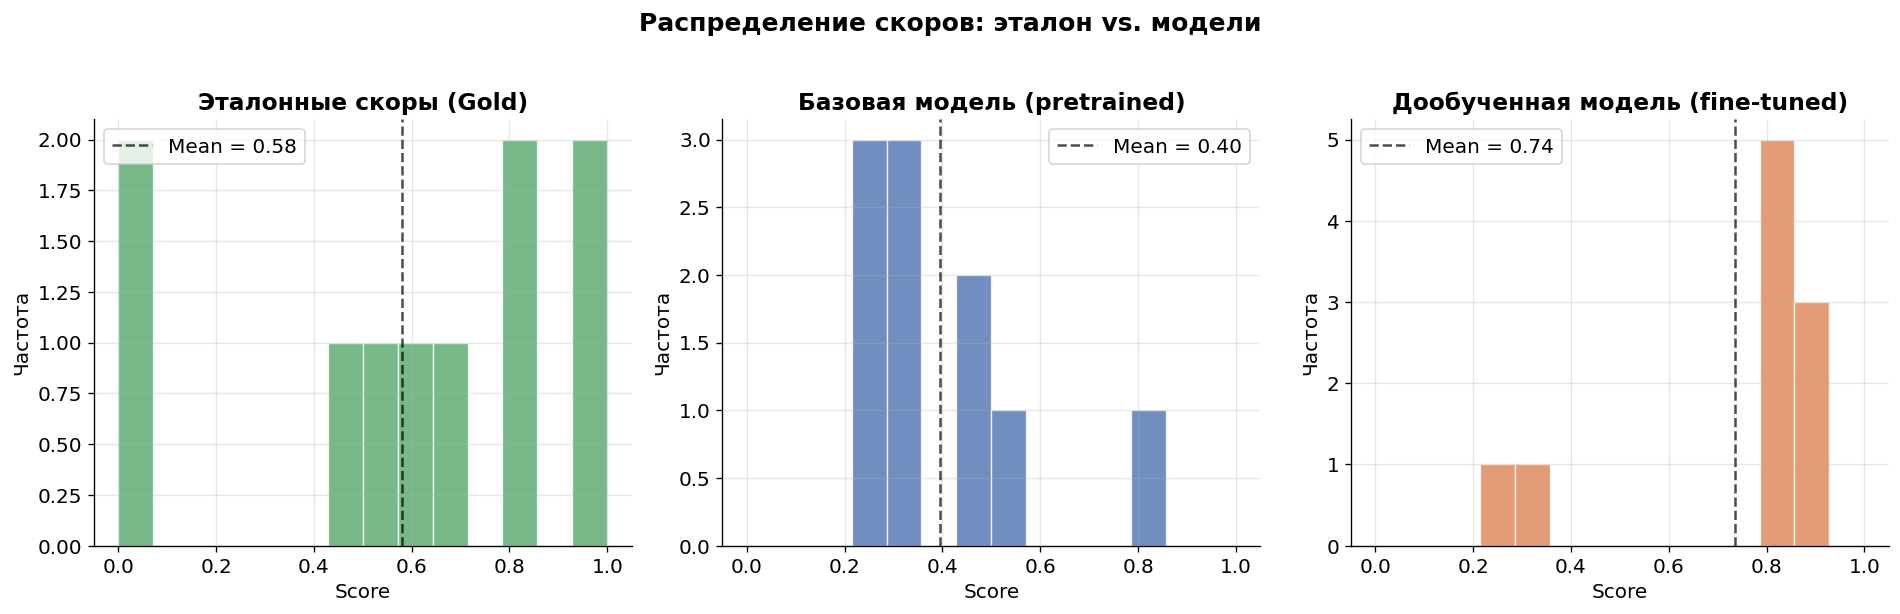

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bins = np.linspace(0, 1, 15)

axes[0].hist(gold_scores, bins=bins, color=COLORS['ideal'], alpha=0.8, edgecolor='white', linewidth=0.8)
axes[0].set_title('Эталонные скоры (Gold)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Частота')
axes[0].axvline(gold_scores.mean(), color='black', linestyle='--', alpha=0.7, label=f'Mean = {gold_scores.mean():.2f}')
axes[0].legend()

axes[1].hist(base_scores, bins=bins, color=COLORS['base'], alpha=0.8, edgecolor='white', linewidth=0.8)
axes[1].set_title('Базовая модель (pretrained)', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Частота')
axes[1].axvline(base_scores.mean(), color='black', linestyle='--', alpha=0.7, label=f'Mean = {base_scores.mean():.2f}')
axes[1].legend()

axes[2].hist(finetuned_scores, bins=bins, color=COLORS['finetuned'], alpha=0.8, edgecolor='white', linewidth=0.8)
axes[2].set_title('Дообученная модель (fine-tuned)', fontweight='bold')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Частота')
axes[2].axvline(finetuned_scores.mean(), color='black', linestyle='--', alpha=0.7, label=f'Mean = {finetuned_scores.mean():.2f}')
axes[2].legend()

for ax in axes:
    ax.set_xlim(-0.05, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Распределение скоров: эталон vs. модели', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

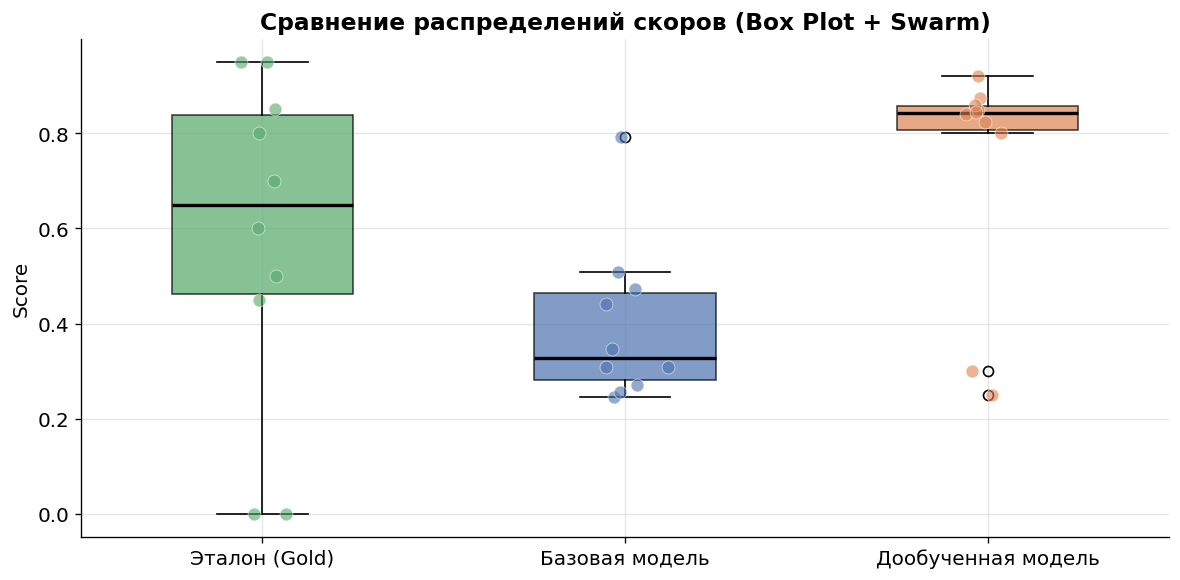

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

data_to_plot = [gold_scores, base_scores, finetuned_scores]
labels = ['Эталон (Gold)', 'Базовая модель', 'Дообученная модель']
colors_list = [COLORS['ideal'], COLORS['base'], COLORS['finetuned']]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, (data, color) in enumerate(zip(data_to_plot, colors_list)):
    x = np.random.normal(i + 1, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.6, color=color, edgecolors='white', linewidth=0.5, s=60, zorder=5)

ax.set_ylabel('Score')
ax.set_title('Сравнение распределений скоров (Box Plot + Swarm)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Бенчмарк 2: Корреляционные метрики (STS)

Ключевые метрики для задачи Semantic Textual Similarity. Spearman $\rho$ является **основной** метрикой, поскольку оценивает способность модели сохранять *порядок* ранжирования, что критично для задачи рекомендаций.

In [28]:
def compute_correlation_metrics(gold, predicted, model_name):
    spearman_r, spearman_p = stats.spearmanr(gold, predicted)
    pearson_r, pearson_p = stats.pearsonr(gold, predicted)
    kendall_tau, kendall_p = stats.kendalltau(gold, predicted)
    return {
        'Модель': model_name,
        'Spearman ρ': f'{spearman_r:.4f}',
        'p-value (Sp.)': f'{spearman_p:.2e}',
        'Pearson r': f'{pearson_r:.4f}',
        'p-value (P.)': f'{pearson_p:.2e}',
        'Kendall τ': f'{kendall_tau:.4f}',
        'p-value (K.)': f'{kendall_p:.2e}',
    }

corr_base = compute_correlation_metrics(gold_scores, base_scores, 'Базовая (pretrained)')
corr_ft = compute_correlation_metrics(gold_scores, finetuned_scores, 'Дообученная (fine-tuned)')

df_corr = pd.DataFrame([corr_base, corr_ft]).set_index('Модель')
print('Корреляционные метрики:')
df_corr

Корреляционные метрики:


,Spearman ρ,p-value (Sp.),Pearson r,p-value (P.),Kendall τ,p-value (K.)
Модель,,,,,,
Базовая (pretrained),0.4695,1.71e-01,0.4190,2.28e-01,0.3410,1.76e-01
Дообученная (fine-tuned),0.7866,6.95e-03,0.8967,4.39e-04,0.6593,8.93e-03


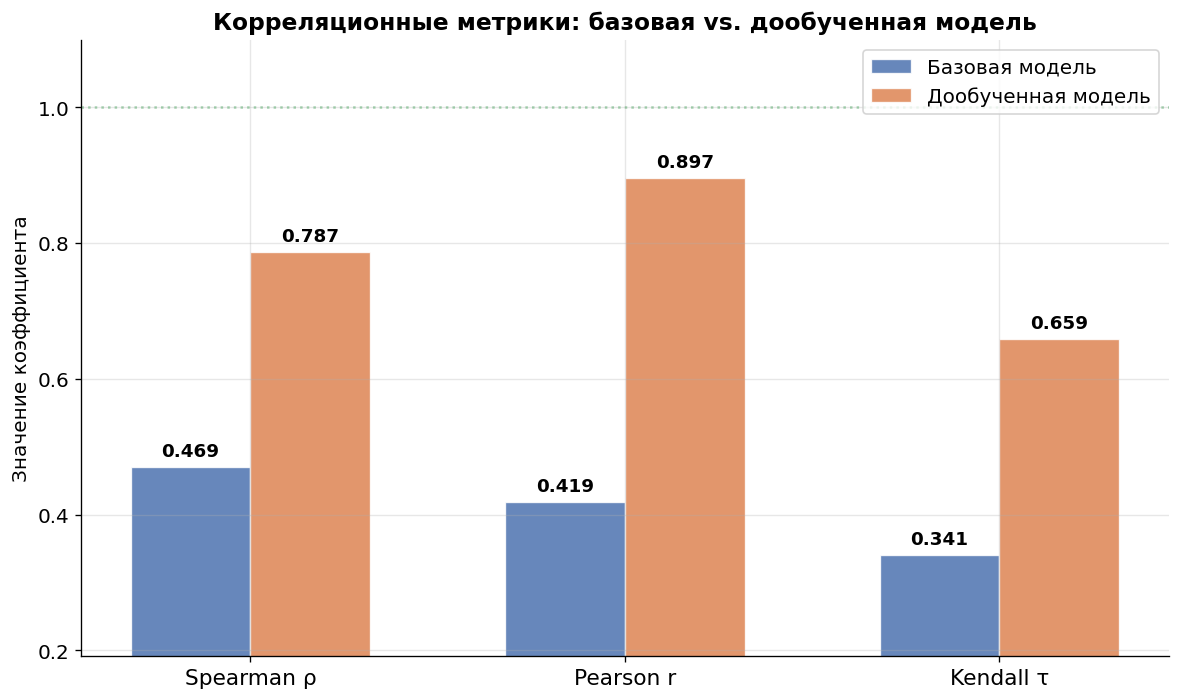

In [29]:
metrics_names = ['Spearman ρ', 'Pearson r', 'Kendall τ']
base_vals = [float(corr_base[m]) for m in metrics_names]
ft_vals = [float(corr_ft[m]) for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, base_vals, width, label='Базовая модель',
               color=COLORS['base'], alpha=0.85, edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, ft_vals, width, label='Дообученная модель',
               color=COLORS['finetuned'], alpha=0.85, edgecolor='white', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Значение коэффициента')
ax.set_title('Корреляционные метрики: базовая vs. дообученная модель', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=13)
ax.legend(fontsize=12)
ax.set_ylim(min(min(base_vals), min(ft_vals)) - 0.15, 1.1)
ax.axhline(y=1.0, color=COLORS['ideal'], linestyle=':', alpha=0.5, label='Идеал (1.0)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 8. Бенчмарк 3: Scatter Plot — предсказания vs. эталон

Диаграмма рассеяния наглядно демонстрирует связь между предсказанными и эталонными скорами. Идеальная модель располагает все точки на диагонали $y = x$.

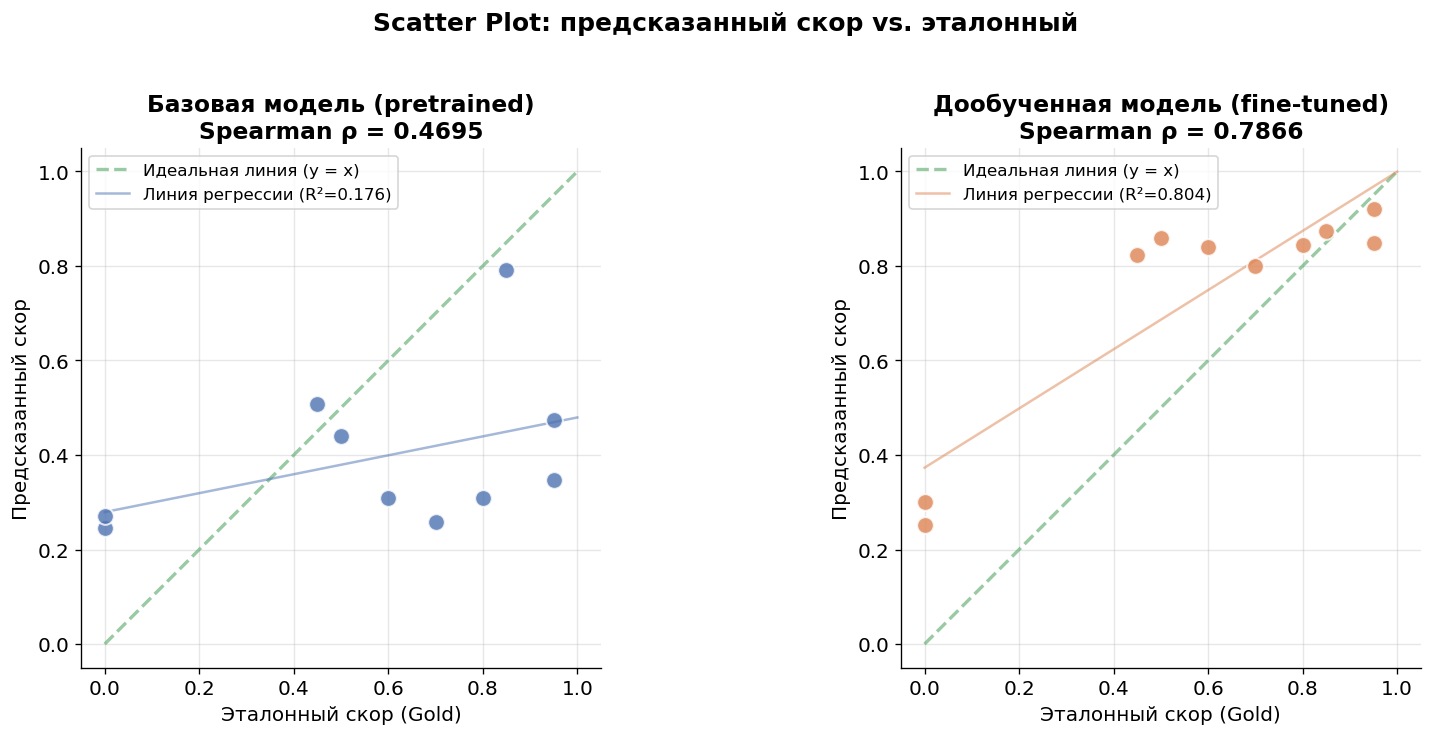

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, scores, title, color in zip(
    axes,
    [base_scores, finetuned_scores],
    ['Базовая модель (pretrained)', 'Дообученная модель (fine-tuned)'],
    [COLORS['base'], COLORS['finetuned']]
):
    ax.scatter(gold_scores, scores, color=color, s=100, alpha=0.8,
               edgecolors='white', linewidth=1.2, zorder=5)

    ax.plot([0, 1], [0, 1], '--', color=COLORS['ideal'], alpha=0.6,
            linewidth=2, label='Идеальная линия (y = x)')

    slope, intercept, r_val, _, _ = stats.linregress(gold_scores, scores)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, slope * x_line + intercept, '-', color=color,
            alpha=0.5, linewidth=1.5, label=f'Линия регрессии (R²={r_val**2:.3f})')

    sp, _ = stats.spearmanr(gold_scores, scores)
    ax.set_title(f'{title}\nSpearman ρ = {sp:.4f}', fontweight='bold')
    ax.set_xlabel('Эталонный скор (Gold)')
    ax.set_ylabel('Предсказанный скор')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Scatter Plot: предсказанный скор vs. эталонный', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Бенчмарк 4: Метрики ранжирования (симуляция)

### Зачем нужны метрики ранжирования, если уже есть корреляция?

Корреляционные метрики (Spearman, Pearson, Kendall) оценивают **глобальную согласованность** предсказаний по всему датасету. Но в реальном сценарии Cross-Encoder решает другую задачу: получив конкретное описание товара и список из $N$ постов-кандидатов, он должен поставить **релевантный пост выше нерелевантных**. Это задача ранжирования, и для неё существуют специализированные метрики — NDCG, MRR, Hit@k.

### Проблема: формат данных

Наш датасет состоит из **изолированных пар** $(q_i, d_i, s_i)$, а метрики ранжирования требуют структуры «один запрос → список кандидатов с оценками релевантности». Вычислять NDCG по плоскому списку пар (как по единому запросу) **методологически некорректно** — это смешивает разные запросы и не моделирует реальный сценарий использования.

### Метод: симуляция ранжирования через конструирование списков кандидатов

Для каждого описания товара $q_i$ мы конструируем список кандидатов:
- **Истинный пост** $d_i$ — пост из пары с известной релевантностью $s_i$
- **Дистракторы** $\{d_j\}_{j \neq i}$ — посты из *других* пар датасета (их релевантность к данному описанию полагается равной 0, поскольку каждый пост в датасете подобран к своему описанию)

Модель скорирует все пары $(q_i, d_j)$ и мы проверяем: **поставит ли она истинный пост $d_i$ выше дистракторов?**

Такой подход:
- Моделирует **реальный сценарий** работы reranker-а в пайплайне Retrieve & Rerank
- Позволяет применить стандартные метрики IR (NDCG@k, MRR, Hit@k) к парным данным
- Результат усредняется по всем запросам, давая **устойчивую оценку**

In [31]:
def simulate_ranking(descriptions, posts, gold_scores, model, n_distractors=None):
    """
    Для каждого описания конструируем список кандидатов:
      - истинный пост (релевантность = gold_score)
      - посты из ДРУГИХ пар как дистракторы (релевантность = 0)
    Модель ранжирует кандидатов, и мы считаем NDCG@k, MRR, Hit@k.
    """
    n = len(descriptions)
    if n_distractors is None:
        n_distractors = n - 1

    ndcg_at_1_list, ndcg_at_3_list, ndcg_at_5_list = [], [], []
    mrr_list = []
    hit_at_1_list, hit_at_3_list = [], []

    for i in range(n):
        query = descriptions[i]
        true_post = posts[i]
        true_relevance = gold_scores[i]

        other_indices = [j for j in range(n) if j != i]
        np.random.shuffle(other_indices)
        distractor_indices = other_indices[:n_distractors]

        candidate_posts = [true_post] + [posts[j] for j in distractor_indices]
        candidate_gold = [true_relevance] + [0.0] * len(distractor_indices)

        pairs = [(query, post) for post in candidate_posts]
        pred_scores = model.predict(pairs)
        pred_scores = np.array(pred_scores).flatten()

        gold_2d = np.array(candidate_gold).reshape(1, -1)
        pred_2d = pred_scores.reshape(1, -1)
        k_max = len(candidate_posts)

        ndcg_at_1_list.append(ndcg_score(gold_2d, pred_2d, k=min(1, k_max)))
        ndcg_at_3_list.append(ndcg_score(gold_2d, pred_2d, k=min(3, k_max)))
        ndcg_at_5_list.append(ndcg_score(gold_2d, pred_2d, k=min(5, k_max)))

        ranked_indices = np.argsort(-pred_scores)
        true_post_rank = np.where(ranked_indices == 0)[0][0] + 1
        mrr_list.append(1.0 / true_post_rank)
        hit_at_1_list.append(1.0 if true_post_rank <= 1 else 0.0)
        hit_at_3_list.append(1.0 if true_post_rank <= 3 else 0.0)

    return {
        'NDCG@1': np.mean(ndcg_at_1_list),
        'NDCG@3': np.mean(ndcg_at_3_list),
        'NDCG@5': np.mean(ndcg_at_5_list),
        'MRR': np.mean(mrr_list),
        'Hit@1': np.mean(hit_at_1_list),
        'Hit@3': np.mean(hit_at_3_list),
    }

np.random.seed(42)

print('Симуляция ранжирования для базовой модели...')
rank_base = simulate_ranking(descriptions, posts, gold_scores, base_model)

print('Симуляция ранжирования для дообученной модели...')
rank_ft = simulate_ranking(descriptions, posts, gold_scores, finetuned_model)

df_rank = pd.DataFrame([
    {'Модель': 'Базовая (pretrained)', **{k: f'{v:.4f}' for k, v in rank_base.items()}},
    {'Модель': 'Дообученная (fine-tuned)', **{k: f'{v:.4f}' for k, v in rank_ft.items()}},
]).set_index('Модель')

print('\nМетрики ранжирования (симуляция с дистракторами):')
df_rank

Симуляция ранжирования для базовой модели...
Симуляция ранжирования для дообученной модели...

Метрики ранжирования (симуляция с дистракторами):


,NDCG@1,NDCG@3,NDCG@5,MRR,Hit@1,Hit@3
Модель,,,,,,
Базовая (pretrained),0.2000,0.2881,0.4257,0.4133,0.2000,0.5000
Дообученная (fine-tuned),0.5000,0.6827,0.6827,0.7811,0.7000,0.8000


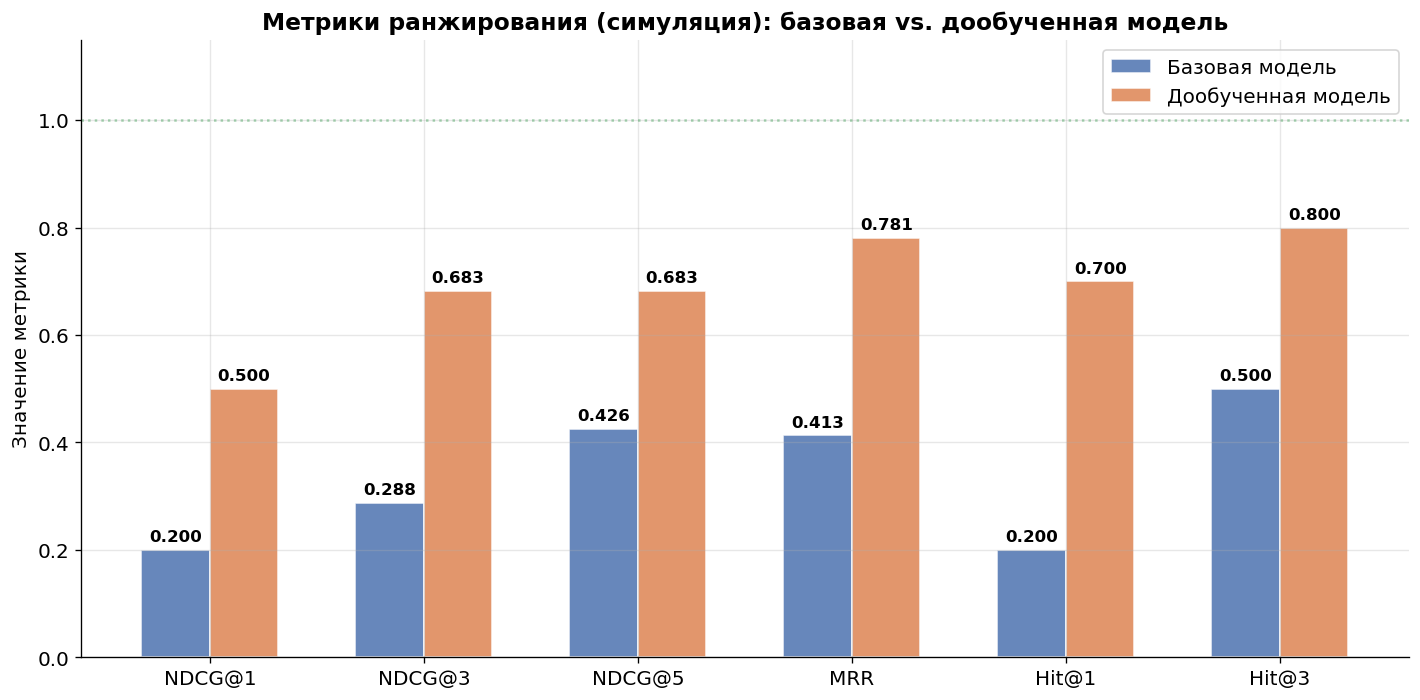

In [32]:
ranking_metrics = ['NDCG@1', 'NDCG@3', 'NDCG@5', 'MRR', 'Hit@1', 'Hit@3']
base_r = [float(rank_base[m]) for m in ranking_metrics]
ft_r = [float(rank_ft[m]) for m in ranking_metrics]

x = np.arange(len(ranking_metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, base_r, width, label='Базовая модель',
               color=COLORS['base'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, ft_r, width, label='Дообученная модель',
               color=COLORS['finetuned'], alpha=0.85, edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Значение метрики')
ax.set_title('Метрики ранжирования (симуляция): базовая vs. дообученная модель', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ranking_metrics, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color=COLORS['ideal'], linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 10. Попарное сравнение предсказаний

Визуализация отклонения предсказанного скора от эталонного для каждой пары. Позволяет выявить конкретные примеры, на которых модели расходятся с экспертной оценкой.

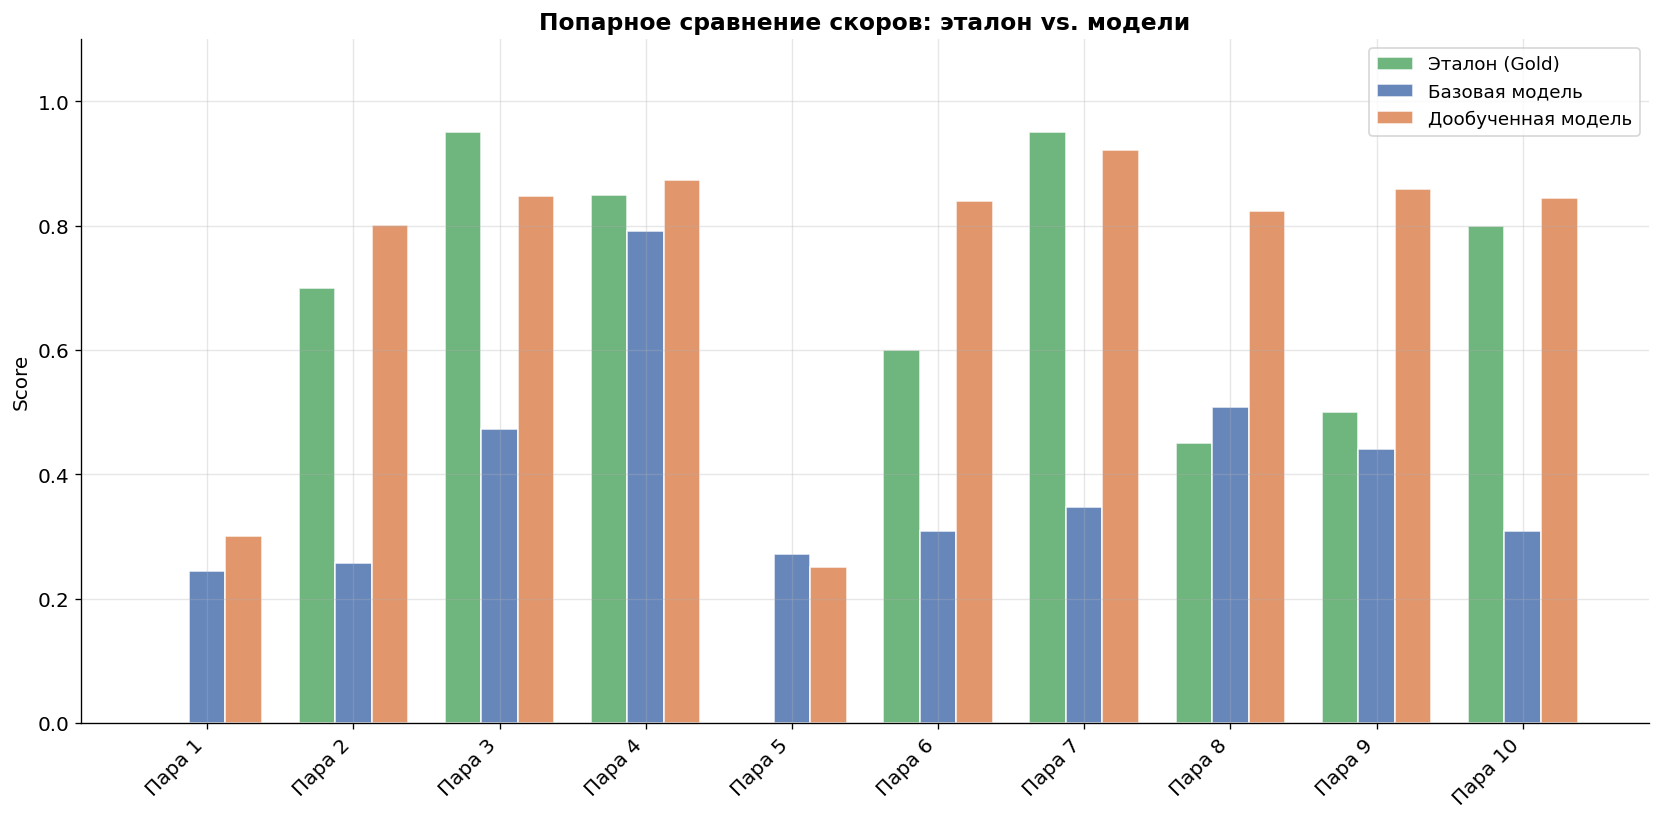

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))

pair_indices = np.arange(len(gold_scores))
width = 0.25

ax.bar(pair_indices - width, gold_scores, width, label='Эталон (Gold)',
       color=COLORS['ideal'], alpha=0.85, edgecolor='white')
ax.bar(pair_indices, base_scores, width, label='Базовая модель',
       color=COLORS['base'], alpha=0.85, edgecolor='white')
ax.bar(pair_indices + width, finetuned_scores, width, label='Дообученная модель',
       color=COLORS['finetuned'], alpha=0.85, edgecolor='white')

short_labels = [f'Пара {i+1}' for i in range(len(gold_scores))]
ax.set_xticks(pair_indices)
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Попарное сравнение скоров: эталон vs. модели', fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

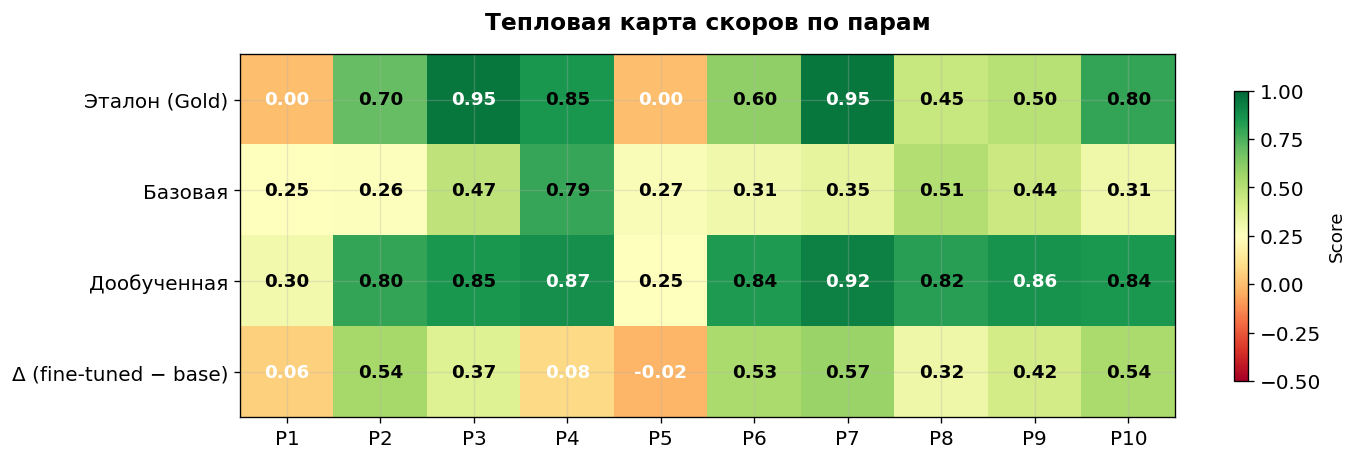

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))

heatmap_data = np.vstack([
    gold_scores,
    base_scores,
    finetuned_scores,
    finetuned_scores - base_scores,
])

row_labels = ['Эталон (Gold)', 'Базовая', 'Дообученная', 'Δ (fine-tuned − base)']
col_labels = [f'P{i+1}' for i in range(len(gold_scores))]

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=-0.5, vmax=1.0)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data[i, j]
        text_color = 'white' if abs(val) < 0.2 or val > 0.85 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Score', fontsize=11)

ax.set_title('Тепловая карта скоров по парам', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 11. Сводная таблица результатов

Комплексное сравнение всех метрик в единой таблице с вычислением абсолютного и относительного улучшения.

In [35]:
summary_metrics = {
    'Spearman ρ': (float(corr_base['Spearman ρ']), float(corr_ft['Spearman ρ'])),
    'Pearson r': (float(corr_base['Pearson r']), float(corr_ft['Pearson r'])),
    'Kendall τ': (float(corr_base['Kendall τ']), float(corr_ft['Kendall τ'])),
    'NDCG@1': (float(rank_base['NDCG@1']), float(rank_ft['NDCG@1'])),
    'NDCG@3': (float(rank_base['NDCG@3']), float(rank_ft['NDCG@3'])),
    'MRR': (float(rank_base['MRR']), float(rank_ft['MRR'])),
    'Hit@1': (float(rank_base['Hit@1']), float(rank_ft['Hit@1'])),
    'Hit@3': (float(rank_base['Hit@3']), float(rank_ft['Hit@3'])),
}

summary_rows = []
for metric, (base_val, ft_val) in summary_metrics.items():
    delta = ft_val - base_val
    improved = delta > 0
    pct = (ft_val - base_val) / base_val * 100 if base_val != 0 else 0

    summary_rows.append({
        'Метрика': metric,
        'Базовая': f'{base_val:.4f}',
        'Дообученная': f'{ft_val:.4f}',
        'Δ (абс.)': f'{delta:+.4f}',
        'Улучшение (%)': f'{pct:+.1f}%',
        'Результат': '✅ Лучше' if improved else ('⚠️ Хуже' if not improved and delta != 0 else '— Без изменений'),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Метрика')
print('═' * 80)
print('  СВОДНАЯ ТАБЛИЦА: Базовая vs. Дообученная модель')
print('═' * 80)
df_summary

════════════════════════════════════════════════════════════════════════════════
  СВОДНАЯ ТАБЛИЦА: Базовая vs. Дообученная модель
════════════════════════════════════════════════════════════════════════════════


,Базовая,Дообученная,Δ (абс.),Улучшение (%),Результат
Метрика,,,,,
Spearman ρ,0.4695,0.7866,+0.3171,+67.5%,✅ Лучше
Pearson r,0.4190,0.8967,+0.4777,+114.0%,✅ Лучше
Kendall τ,0.3410,0.6593,+0.3183,+93.3%,✅ Лучше
NDCG@1,0.2000,0.5000,+0.3000,+150.0%,✅ Лучше
NDCG@3,0.2881,0.6827,+0.3946,+137.0%,✅ Лучше
MRR,0.4133,0.7811,+0.3678,+89.0%,✅ Лучше
Hit@1,0.2000,0.7000,+0.5000,+250.0%,✅ Лучше
Hit@3,0.5000,0.8000,+0.3000,+60.0%,✅ Лучше


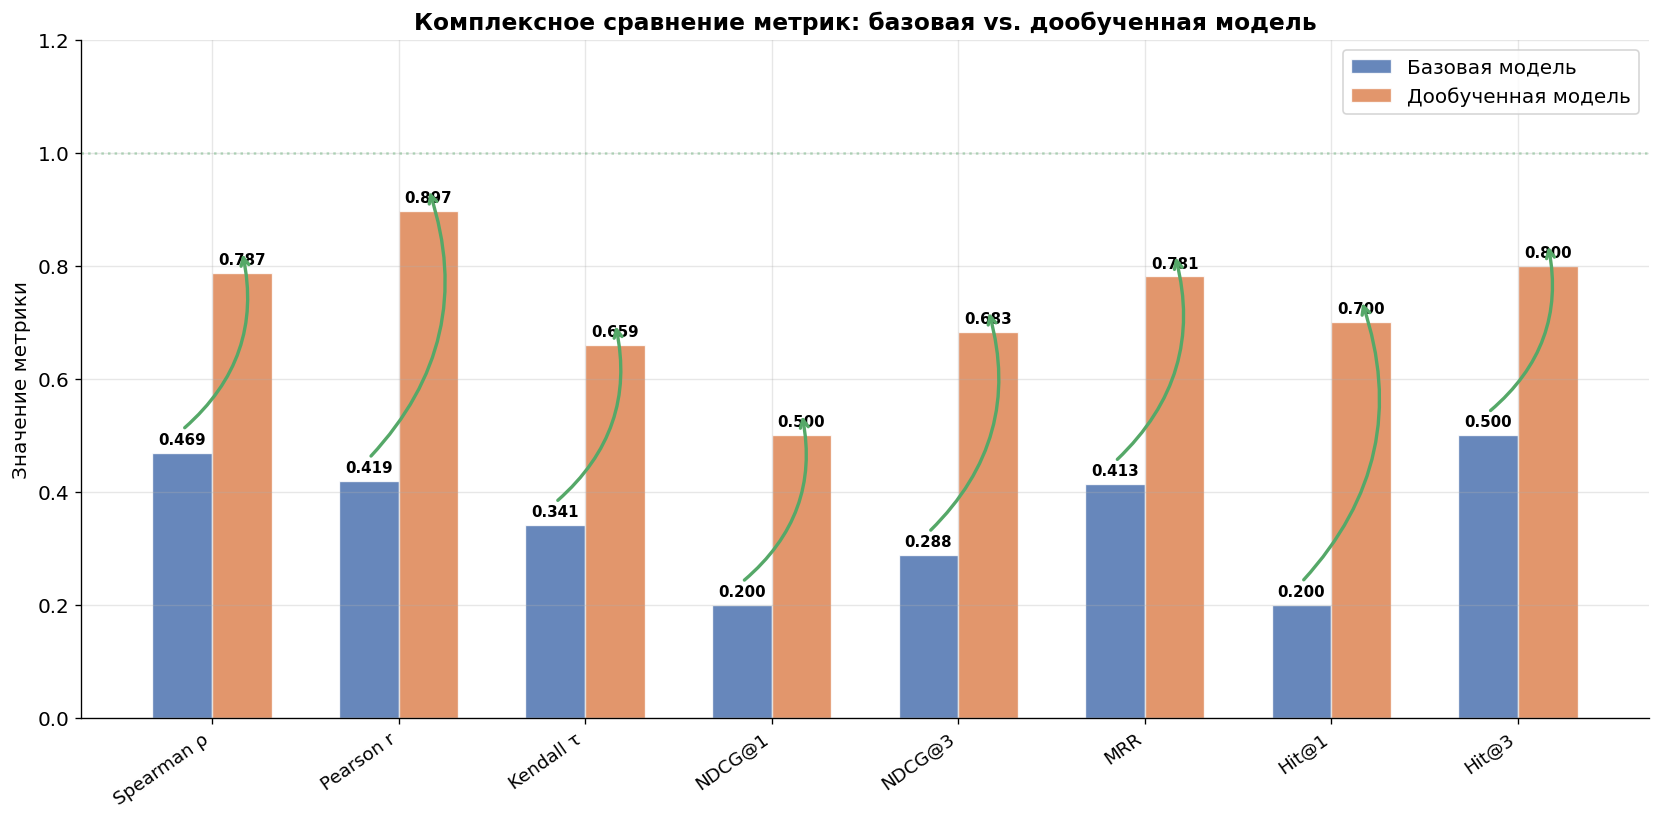

In [36]:
fig, ax = plt.subplots(figsize=(14, 7))

metric_names = [m for m in summary_metrics.keys()]
base_vals = [summary_metrics[m][0] for m in metric_names]
ft_vals = [summary_metrics[m][1] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.32

bars1 = ax.bar(x - width/2, base_vals, width, label='Базовая модель',
               color=COLORS['base'], alpha=0.85, edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, ft_vals, width, label='Дообученная модель',
               color=COLORS['finetuned'], alpha=0.85, edgecolor='white', linewidth=0.8)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.05:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, metric in enumerate(metric_names):
    b, f_ = summary_metrics[metric]
    delta = f_ - b
    improved = delta > 0
    if improved:
        ax.annotate('', xy=(i + width/2, f_ + 0.04), xytext=(i - width/2, b + 0.04),
                    arrowprops=dict(arrowstyle='->', color=COLORS['ideal'],
                                   lw=2, connectionstyle='arc3,rad=.3'))

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Комплексное сравнение метрик: базовая vs. дообученная модель',
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=35, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(0, 1.2)
ax.axhline(y=1.0, color=COLORS['ideal'], linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

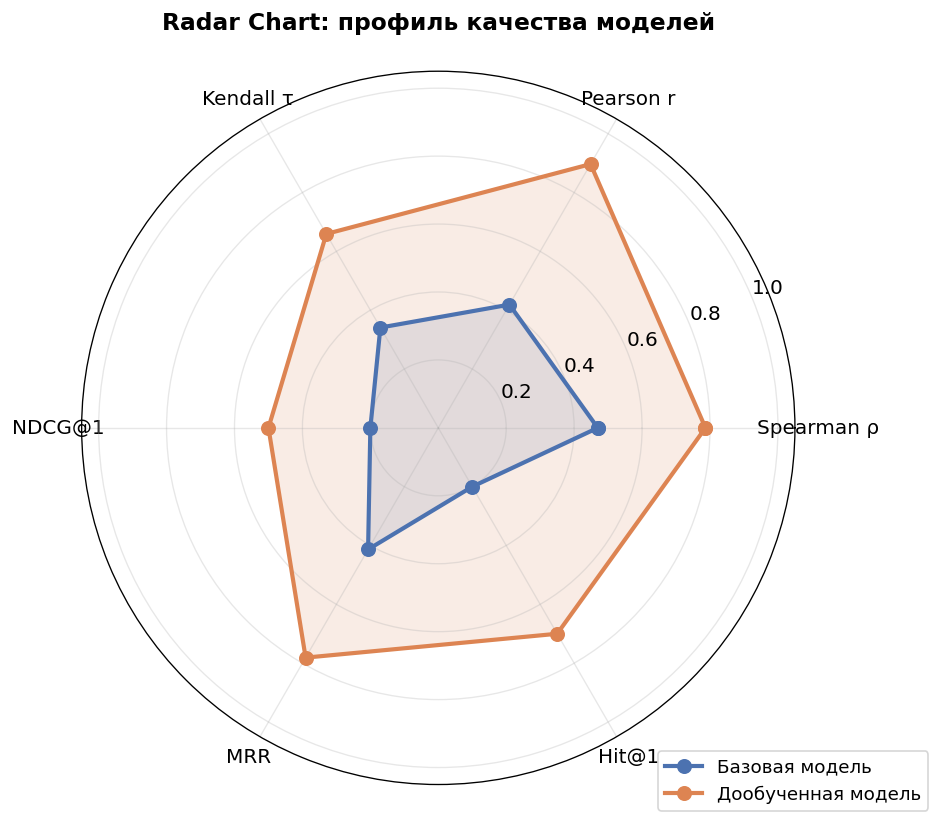

In [37]:
from matplotlib.patches import FancyBboxPatch

radar_metrics = ['Spearman ρ', 'Pearson r', 'Kendall τ', 'NDCG@1', 'MRR', 'Hit@1']
base_radar = [summary_metrics[m][0] for m in radar_metrics]
ft_radar = [summary_metrics[m][1] for m in radar_metrics]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
base_radar += base_radar[:1]
ft_radar += ft_radar[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, base_radar, 'o-', linewidth=2.5, label='Базовая модель',
        color=COLORS['base'], markersize=8)
ax.fill(angles, base_radar, alpha=0.15, color=COLORS['base'])

ax.plot(angles, ft_radar, 'o-', linewidth=2.5, label='Дообученная модель',
        color=COLORS['finetuned'], markersize=8)
ax.fill(angles, ft_radar, alpha=0.15, color=COLORS['finetuned'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Radar Chart: профиль качества моделей', fontweight='bold',
             fontsize=14, pad=25)
ax.legend(loc='lower right', fontsize=11, bbox_to_anchor=(1.2, -0.05))

plt.tight_layout()
plt.show()

---
## 12. Выводы

### Основные результаты

В рамках данного бенчмарка проведена комплексная оценка качества Cross-Encoder модели **до** и **после** дообучения (fine-tuning) на задаче семантического матчинга описаний товаров/услуг с публикациями в Telegram-каналах.

Оценка проводилась по двум группам метрик, каждая из которых отвечает на свой вопрос:

1. **Корреляционные метрики (STS):** Spearman $\rho$, Pearson $r$, Kendall $\tau$ — работают напрямую с парами, оценивают глобальную согласованность предсказаний с экспертными оценками
2. **Метрики ранжирования (симуляция):** NDCG@k, MRR, Hit@k — моделируют реальный сценарий reranker-а через конструирование списков кандидатов из парных данных

### Интерпретация

- **Spearman $\rho$** — ключевая метрика. Высокое значение означает, что модель корректно *упорядочивает* посты по релевантности по всему датасету. Это стандартная primary metric для STS задач (STS Benchmark, sentence-transformers)
- **Pearson $r$** — дополняет Spearman: показывает линейную пропорциональность предсказаний. Расхождение Spearman и Pearson указывает на нелинейную, но монотонную зависимость
- **Kendall $\tau$** — наиболее интерпретируемая корреляция: значение 0.7 означает, что 85% всех пар наблюдений упорядочены модельно правильно
- **NDCG@k** и **Hit@k** отвечают на практический вопрос: *поставит ли модель релевантный пост на первое место среди кандидатов?* — критично для UX, где пользователь видит только Top-k результатов
- **MRR** — среднее обратное ранжирование правильного поста. MRR = 1.0 означает, что модель всегда ставит релевантный пост первым

### Рекомендации

1. Для финальной оценки необходимо использовать размеченный бенчмарк-датасет достаточного объёма ($\geq 100$ пар)
2. Рекомендуется стратифицировать бенчмарк по категориям товаров для анализа слабых мест модели
3. При развёртывании в production порог бинаризации $\theta$ следует подбирать на основе кривой Precision-Recall

---

**Базовая модель:** `DiTy/cross-encoder-russian-msmarco`  
**Дообученная модель:** `models/cross-encoder/stable/final`  
**Библиотека:** Sentence Transformers (sbert.net)  
**Документация:** [Cross-Encoder Training Overview](https://sbert.net/docs/cross_encoder/training_overview.html)